Chargement de la carte pour : Paris, France...
affichage en cours...


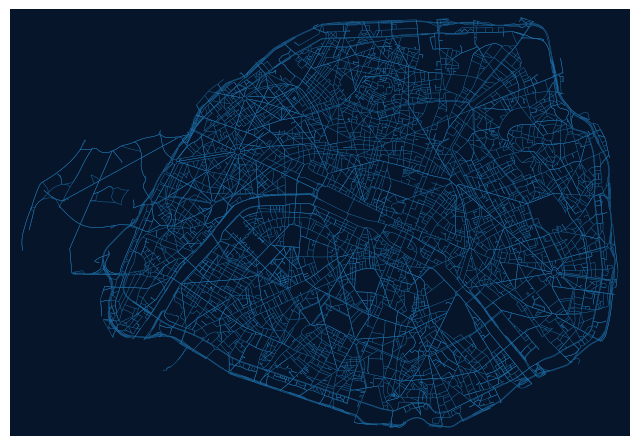

Carte de Paris générée !


In [28]:
import osmnx as ox
import matplotlib.pyplot as plt

#definir le lieu que l'on veut extraire
place_name = "Paris, France"

print(f"Chargement de la carte pour : {place_name}...")

# Télécharger tout l'intérieur de Paris
G = ox.graph_from_place("Paris, France", network_type='drive')

#aficher la carte
print('affichage en cours...')
fig, ax = ox.plot_graph(
    G,
    bgcolor="#061529",
    edge_color="#1f77b4",
    edge_linewidth=0.3,
    node_size=0,
    show=True,
    close=False
)

print("Carte de Paris générée !")
plt.show()

In [29]:
#on s'assure que chaque rue a bien une longueur calculé
G = ox.add_edge_speeds(G) # Ajoute la vitesse limite
G = ox.add_edge_travel_times(G) #calcule du temps de trajet theorique
print("Données de navigation ajoutées avec succès !")

Données de navigation ajoutées avec succès !


In [30]:
import sklearn
print("Scikit-learn est bien installé !")
#on recupere la liste des moeud
nodes = list(G.nodes())

# 2. On définit deux adresses à Paris
adresse_depart = "Place de la Bastille, Paris"
adresse_arrivee = "Arc de Triomphe, Paris"

# 3 on geocode  les adress
coords_dep = ox.geocode(adresse_depart)
coords_arr = ox.geocode(adresse_arrivee)

#on trouve les meud les plus proche de ces points

node_dep = ox.nearest_nodes(G, X = coords_dep[1], Y = coords_dep[0])
node_arr = ox.nearest_nodes(G, X = coords_arr[1], Y = coords_arr[0])

print(f"Départ (ID) : {node_dep}")
print(f"Arrivée (ID) : {node_arr}")

Scikit-learn est bien installé !
Départ (ID) : 332476879
Arrivée (ID) : 368313


In [31]:
import requests

def get_paris_weather_factor():
    """
    Récupère la météo en direct à Paris.
    Retourne 0.7 si pluie/neige (ralentissement de 30%), sinon 1.0.
    """
    url = "https://api.open-meteo.com/v1/forecast?latitude=48.8534&longitude=2.3488&current_weather=true"

    try:
        response = requests.get(url).json()
        weather_code = response['current_weather']['weathercode']

        # Les codes 51, 61, 80 etc. correspondent à la pluie
        if weather_code >= 51:
            print("🌧️ Il pleut à Paris ! Le trafic va être plus lent.")
            return 0.7
        else:
            print("☀️ Beau temps à Paris.")
            return 1.0
    except:
        return 1.0

In [32]:
import numpy as np
def get_traffic_factor(hour):
    """
    Simule un coefficient de trafic entre 0.1 (bouchon total) et 1.0 (fluide)
    Basé sur une courbe simplifiée des pics parisiens.
    """
    #on simule deux pics avec une fonction sinus/cosinus
    #une approximationpolinomiale du comportement reel
    factor = 0.5 * 0.4 * np.cos(hour * np.pi / 10)
    return max(0.1, min(1.0, factor))

for h in [8, 14, 18]:
    print(f"À {h}h, le trafic est à {get_traffic_factor(h)*100:.0f}% de sa capacité.")

À 8h, le trafic est à 10% de sa capacité.
À 14h, le trafic est à 10% de sa capacité.
À 18h, le trafic est à 16% de sa capacité.


In [33]:
def update_map_with_traffic(graph, hour):
    # On récupère le facteur de bouchon pour cette heure
    hour_factor = get_traffic_factor(hour)

    # facteur meteo
    weather_factor = get_paris_weather_factor()

    # Facteur global combiné
    global_factor = hour_factor * weather_factor

    # On parcourt chaque rue (edge) du graphe
    for u, v, data in graph.edges(data=True):
        #vitesse de base
        max_speed = data.get("speed_kph", 30)

        # vitesse reel avec bouchon
        real_speed = max_speed * global_factor

        #calcul du temps de trajet en secoconde
        distance = data["length"]
        data["travel_time_traffic"] = distance / (real_speed / 3.6)
    print(f"Carte mise à jour pour {hour}h00 (Vitesse moyenne : {global_factor*100:.0f}% du max)")

# Testons avec l'heure actuelle
import datetime
current_hour = datetime.datetime.now().hour
update_map_with_traffic(G, current_hour)

☀️ Beau temps à Paris.
Carte mise à jour pour 0h00 (Vitesse moyenne : 20% du max)


☀️ Beau temps à Paris.
Carte mise à jour pour 7h00 (Vitesse moyenne : 10% du max)
Temps de trajet estimé à 8h00 : 109.2 minutes


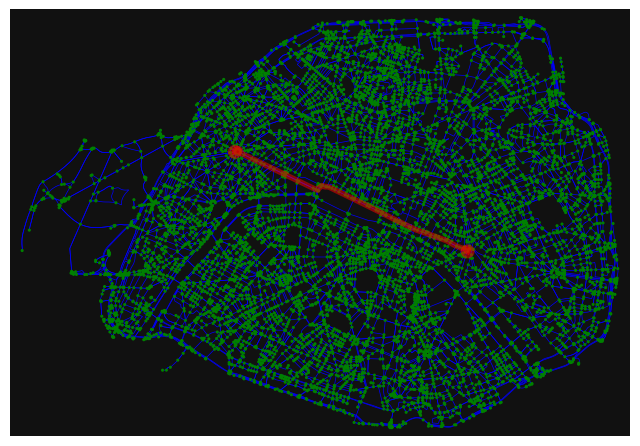

In [35]:
import networkx as nx

# 1 on met a jour la carte pour 8h du matin (Pic due trafic)
update_map_with_traffic(G, 7)

# 2 Calcul du chemin le plus court en temps (avec trafic)
try:
    route_trafic = nx.shortest_path(G, node_dep, node_arr, weight="travel_time_traffic")

    # 3 calculer le temps total en minutes
    #on additionne le trajet temps reel de chaque segment du chemin
    total_seconds = nx.shortest_path_length(G, node_dep, node_arr, weight="travel_time_traffic")
    print(f"Temps de trajet estimé à 8h00 : {total_seconds/60:.1f} minutes")

    # 4 afficher le resultat
    ox.plot_graph_route(G, route_trafic, route_color="red", node_color="green", edge_color="blue", edge_linewidth=0.5, node_size=5)

except nx.NetworkXNoPath:
    print("Pas de chemin trouvé entre ces deux points. Réessaie en relançant la cellule précédente (choix des nœuds).")

📥 Téléchargement de la carte : Paris, France...
✅ Trafic injecté. Fluidité actuelle : 26.5%


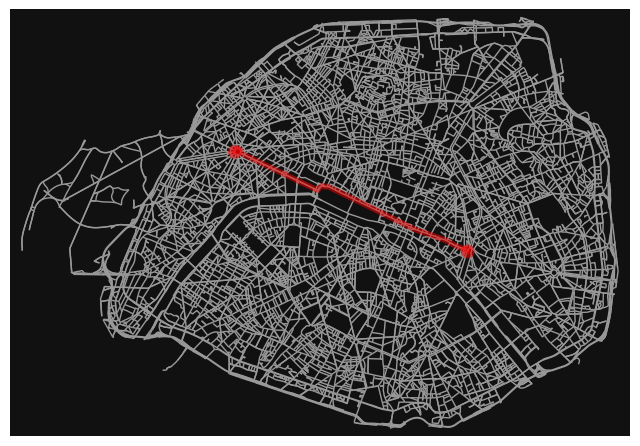

In [36]:
import osmnx as ox
import networkx as nx
import numpy as np
import requests
import matplotlib.pyplot as plt
from datetime import datetime

# --- CONFIGURATION ---
PLACE_NAME = "Paris, France"

# 1. FONCTION : CHARGER LA CARTE
def charger_carte(nom_lieu):
    print(f"📥 Téléchargement de la carte : {nom_lieu}...")
    # On récupère le réseau routier
    G = ox.graph_from_place(nom_lieu, network_type='drive')
    # On pré-calcule les données de base (vitesse et temps théorique)
    G = ox.add_edge_speeds(G)
    G = ox.add_edge_travel_times(G)
    return G

# 2. FONCTION : MODÈLE DE TRAFIC (MATHS)
def calculer_facteur_heure(heure):
    # Courbe sinusoïdale pour simuler les pics de 8h et 18h
    # On ajuste la formule pour avoir des creux réalistes
    factor = 0.5 + 0.4 * np.cos((heure - 13) * np.pi / 10)
    return max(0.1, min(1.0, factor))

# 3. FONCTION : MÉTÉO RÉELLE (API)
def calculer_facteur_meteo():
    url = "https://api.open-meteo.com/v1/forecast?latitude=48.8534&longitude=2.3488&current_weather=true"
    try:
        r = requests.get(url).json()
        code = r['current_weather']['weathercode']
        return 0.7 if code >= 51 else 1.0 # 0.7 = -30% de vitesse s'il pleut
    except:
        return 1.0

# 4. FONCTION : MISE À JOUR DU GRAPHE
def injecter_trafic(graph, heure):
    f_heure = calculer_facteur_heure(heure)
    f_meteo = calculer_facteur_meteo()
    f_global = f_heure * f_meteo

    for u, v, data in graph.edges(data=True):
        vitesse_max = data.get("speed_kph", 30)
        vitesse_reelle = vitesse_max * f_global
        # Distance (m) / Vitesse (m/s) -> Temps (s)
        data["travel_time_traffic"] = data["length"] / (vitesse_reelle / 3.6)

    return f_global

# --- PROGRAMME PRINCIPAL ---
if __name__ == "__main__":
    # A. Initialisation
    G = charger_carte(PLACE_NAME)
    heure_actuelle = datetime.now().hour

    # B. Simulation du trafic
    fluidite = injecter_trafic(G, heure_actuelle)
    print(f"✅ Trafic injecté. Fluidité actuelle : {fluidite*100:.1f}%")

    # C. Itinéraire (Exemple Bastille -> Arc de Triomphe)
    dep = ox.geocode("Place de la Bastille, Paris")
    arr = ox.geocode("Arc de Triomphe, Paris")

    node_dep = ox.nearest_nodes(G, X=dep[1], Y=dep[0])
    node_arr = ox.nearest_nodes(G, X=arr[1], Y=arr[0])

    route = nx.shortest_path(G, node_dep, node_arr, weight="travel_time_traffic")

    # D. Affichage
    ox.plot_graph_route(G, route, route_color="red", node_size=0)
    plt.show()